<a href="https://colab.research.google.com/github/mirdanish6594/CO2-Capture-ML/blob/main/Final_With_Updated_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.neural_network import MLPRegressor

import shap

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/CO2-Capture-ML/Data/Processed/Final_Dataset_With_Physicochemical_Properties.csv'


df = pd.read_csv(DATA_PATH)

print(df.shape)

display(df.head())

Mounted at /content/drive
(879, 51)


,temperature_k,CO2 Loading (mol/mol_alk),PCO2* (Pa),Target -> kg′ (mol/s·Pa·m²),conc_aep_m,conc_amp_m,conc_dga_m,conc_dmpz_m,conc_eda_m,conc_hep_m,...,Kappa2,Kappa3,dominant_amine,pKa,BoilingPoint_C,MeltingPoint_C,VaporPressure_kPa,WaterSolubility_gL,Density_gmL,Viscosity_mPas
0,332.307021,0.386960,896.373227,1.470000e-06,0.0,0.0,0.0,0.0,0.0,0.0,...,2.920000,1.920000,conc_mea_m,9.50,170.5,10.5,0.047996,1000,1.011,21.10
1,373.150000,0.063000,6530.000000,2.530000e-06,0.0,0.0,0.0,0.0,0.0,7.7,...,5.960000,5.960000,conc_hep_m,10.67,224.0,28.0,0.001333,1000,0.870,5.60
2,374.737183,0.131455,30339.227705,6.700000e-07,0.0,0.0,0.0,0.0,0.0,7.7,...,5.960000,5.960000,conc_hep_m,10.67,224.0,28.0,0.001333,1000,0.870,5.60
3,374.693934,0.372540,19293.602409,1.400000e-06,0.0,0.0,0.0,0.0,0.0,0.0,...,2.920000,1.920000,conc_mea_m,9.50,170.5,10.5,0.047996,1000,1.011,21.10
4,353.150000,0.253000,9720.000000,1.370000e-06,0.0,0.0,0.0,0.0,0.0,0.0,...,2.284555,1.450252,conc_mpz_m,9.57,138.0,-29.0,0.390633,1000,0.902,1.88


In [ ]:
TARGET = 'log_k'

print(df.columns)

Index(['temperature_k', 'CO2 Loading (mol/mol_alk)', 'PCO2* (Pa)',
       'Target -> kg′ (mol/s·Pa·m²)', 'conc_aep_m', 'conc_amp_m', 'conc_dga_m',
       'conc_dmpz_m', 'conc_eda_m', 'conc_hep_m', 'conc_mapa_m', 'conc_mdea_m',
       'conc_mea_m', 'conc_mpz_m', 'conc_pe_m', 'conc_pz_m', 'MolWt',
       'ExactMolWt', 'MolLogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds',
       'RingCount', 'HeavyAtomCount', 'FractionCSP3', 'NOCount', 'NHOHCount',
       'NumAliphaticRings', 'NumAromaticRings', 'NumAliphaticCarbocycles',
       'NumAromaticCarbocycles', 'NumAliphaticHeterocycles',
       'NumAromaticHeterocycles', 'NumValenceElectrons', 'LabuteASA', 'MolMR',
       'Chi0v', 'Chi1v', 'Chi2v', 'Kappa1', 'Kappa2', 'Kappa3',
       'dominant_amine', 'pKa', 'BoilingPoint_C', 'MeltingPoint_C',
       'VaporPressure_kPa', 'WaterSolubility_gL', 'Density_gmL',
       'Viscosity_mPas'],
      dtype='object')


In [ ]:
import numpy as np

df['log_k'] = np.log10(df["Target -> kg′ (mol/s·Pa·m²)"])
TARGET = 'log_k'

remove_cols = ['dominant_amine']
remove_cols = [c for c in remove_cols if c in df.columns]

X = df.drop(columns=[TARGET, "Target -> kg′ (mol/s·Pa·m²)"] + remove_cols)
y = df[TARGET]

In [ ]:
remove_cols = [
    'dominant_amine'
]

remove_cols = [c for c in remove_cols if c in df.columns]

X = df.drop(columns=[TARGET] + remove_cols)

y = df[TARGET]

print(X.shape)
print(y.shape)

(879, 50)
(879,)


In [ ]:
constant_cols = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print('Constant Columns:', constant_cols)

X = X.drop(columns=constant_cols)

print(X.shape)

Constant Columns: ['FractionCSP3', 'NumAromaticRings', 'NumAliphaticCarbocycles', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles']
(879, 45)


In [ ]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

protected = [
    'temperature_k',
    'PCO2* (Pa)',
    'CO2 Loading (mol/mol_alk)'
]

to_drop = []

for col in upper.columns:
    if col in protected:
        continue

    if any(upper[col] > 0.95):
        to_drop.append(col)

print('Dropping:', to_drop)

X = X.drop(columns=to_drop)

print(X.shape)

Dropping: ['ExactMolWt', 'HeavyAtomCount', 'NOCount', 'NumAliphaticRings', 'NumAliphaticHeterocycles', 'NumValenceElectrons', 'LabuteASA', 'MolMR', 'Chi0v', 'Chi1v', 'Kappa2']
(879, 34)


In [ ]:
# ============================================================
# REMOVE ROWS WITH MISSING TARGET
# ============================================================

print("Before:", df.shape)

df = df.dropna(
    subset=['Target -> kg′ (mol/s·Pa·m²)']
)

print("After:", df.shape)

Before: (879, 52)
After: (870, 52)


In [ ]:
print(df.columns)

Index(['temperature_k', 'CO2 Loading (mol/mol_alk)', 'PCO2* (Pa)',
       'Target -> kg′ (mol/s·Pa·m²)', 'conc_aep_m', 'conc_amp_m', 'conc_dga_m',
       'conc_dmpz_m', 'conc_eda_m', 'conc_hep_m', 'conc_mapa_m', 'conc_mdea_m',
       'conc_mea_m', 'conc_mpz_m', 'conc_pe_m', 'conc_pz_m', 'MolWt',
       'ExactMolWt', 'MolLogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds',
       'RingCount', 'HeavyAtomCount', 'FractionCSP3', 'NOCount', 'NHOHCount',
       'NumAliphaticRings', 'NumAromaticRings', 'NumAliphaticCarbocycles',
       'NumAromaticCarbocycles', 'NumAliphaticHeterocycles',
       'NumAromaticHeterocycles', 'NumValenceElectrons', 'LabuteASA', 'MolMR',
       'Chi0v', 'Chi1v', 'Chi2v', 'Kappa1', 'Kappa2', 'Kappa3',
       'dominant_amine', 'pKa', 'BoilingPoint_C', 'MeltingPoint_C',
       'VaporPressure_kPa', 'WaterSolubility_gL', 'Density_gmL',
       'Viscosity_mPas', 'log_k'],
      dtype='object')


In [ ]:
print("Before:", df.shape)

df = df.dropna(
    subset=['log_k']
)

print("After:", df.shape)

Before: (870, 52)
After: (870, 52)


In [ ]:
TARGET = 'log_k'

X = df.drop(columns=[
    'log_k',
    'Target -> kg′ (mol/s·Pa·m²)',
    'dominant_amine'
])

y = df[TARGET]

print(X.shape)
print(y.shape)

(870, 49)
(870,)


In [ ]:
X = X.apply(
    pd.to_numeric,
    errors='coerce'
)

In [ ]:
print(X.isnull().sum().sum())

X = X.fillna(X.median())

print(X.isnull().sum().sum())

0
0


In [ ]:
print("Final Number of Features:")
print(len(X.columns))

print("\nFeatures:")
print(X.columns.tolist())

Final Number of Features:
49

Features:
['temperature_k', 'CO2 Loading (mol/mol_alk)', 'PCO2* (Pa)', 'conc_aep_m', 'conc_amp_m', 'conc_dga_m', 'conc_dmpz_m', 'conc_eda_m', 'conc_hep_m', 'conc_mapa_m', 'conc_mdea_m', 'conc_mea_m', 'conc_mpz_m', 'conc_pe_m', 'conc_pz_m', 'MolWt', 'ExactMolWt', 'MolLogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'RingCount', 'HeavyAtomCount', 'FractionCSP3', 'NOCount', 'NHOHCount', 'NumAliphaticRings', 'NumAromaticRings', 'NumAliphaticCarbocycles', 'NumAromaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAromaticHeterocycles', 'NumValenceElectrons', 'LabuteASA', 'MolMR', 'Chi0v', 'Chi1v', 'Chi2v', 'Kappa1', 'Kappa2', 'Kappa3', 'pKa', 'BoilingPoint_C', 'MeltingPoint_C', 'VaporPressure_kPa', 'WaterSolubility_gL', 'Density_gmL', 'Viscosity_mPas']


Generating Clean Full Correlation Matrix...


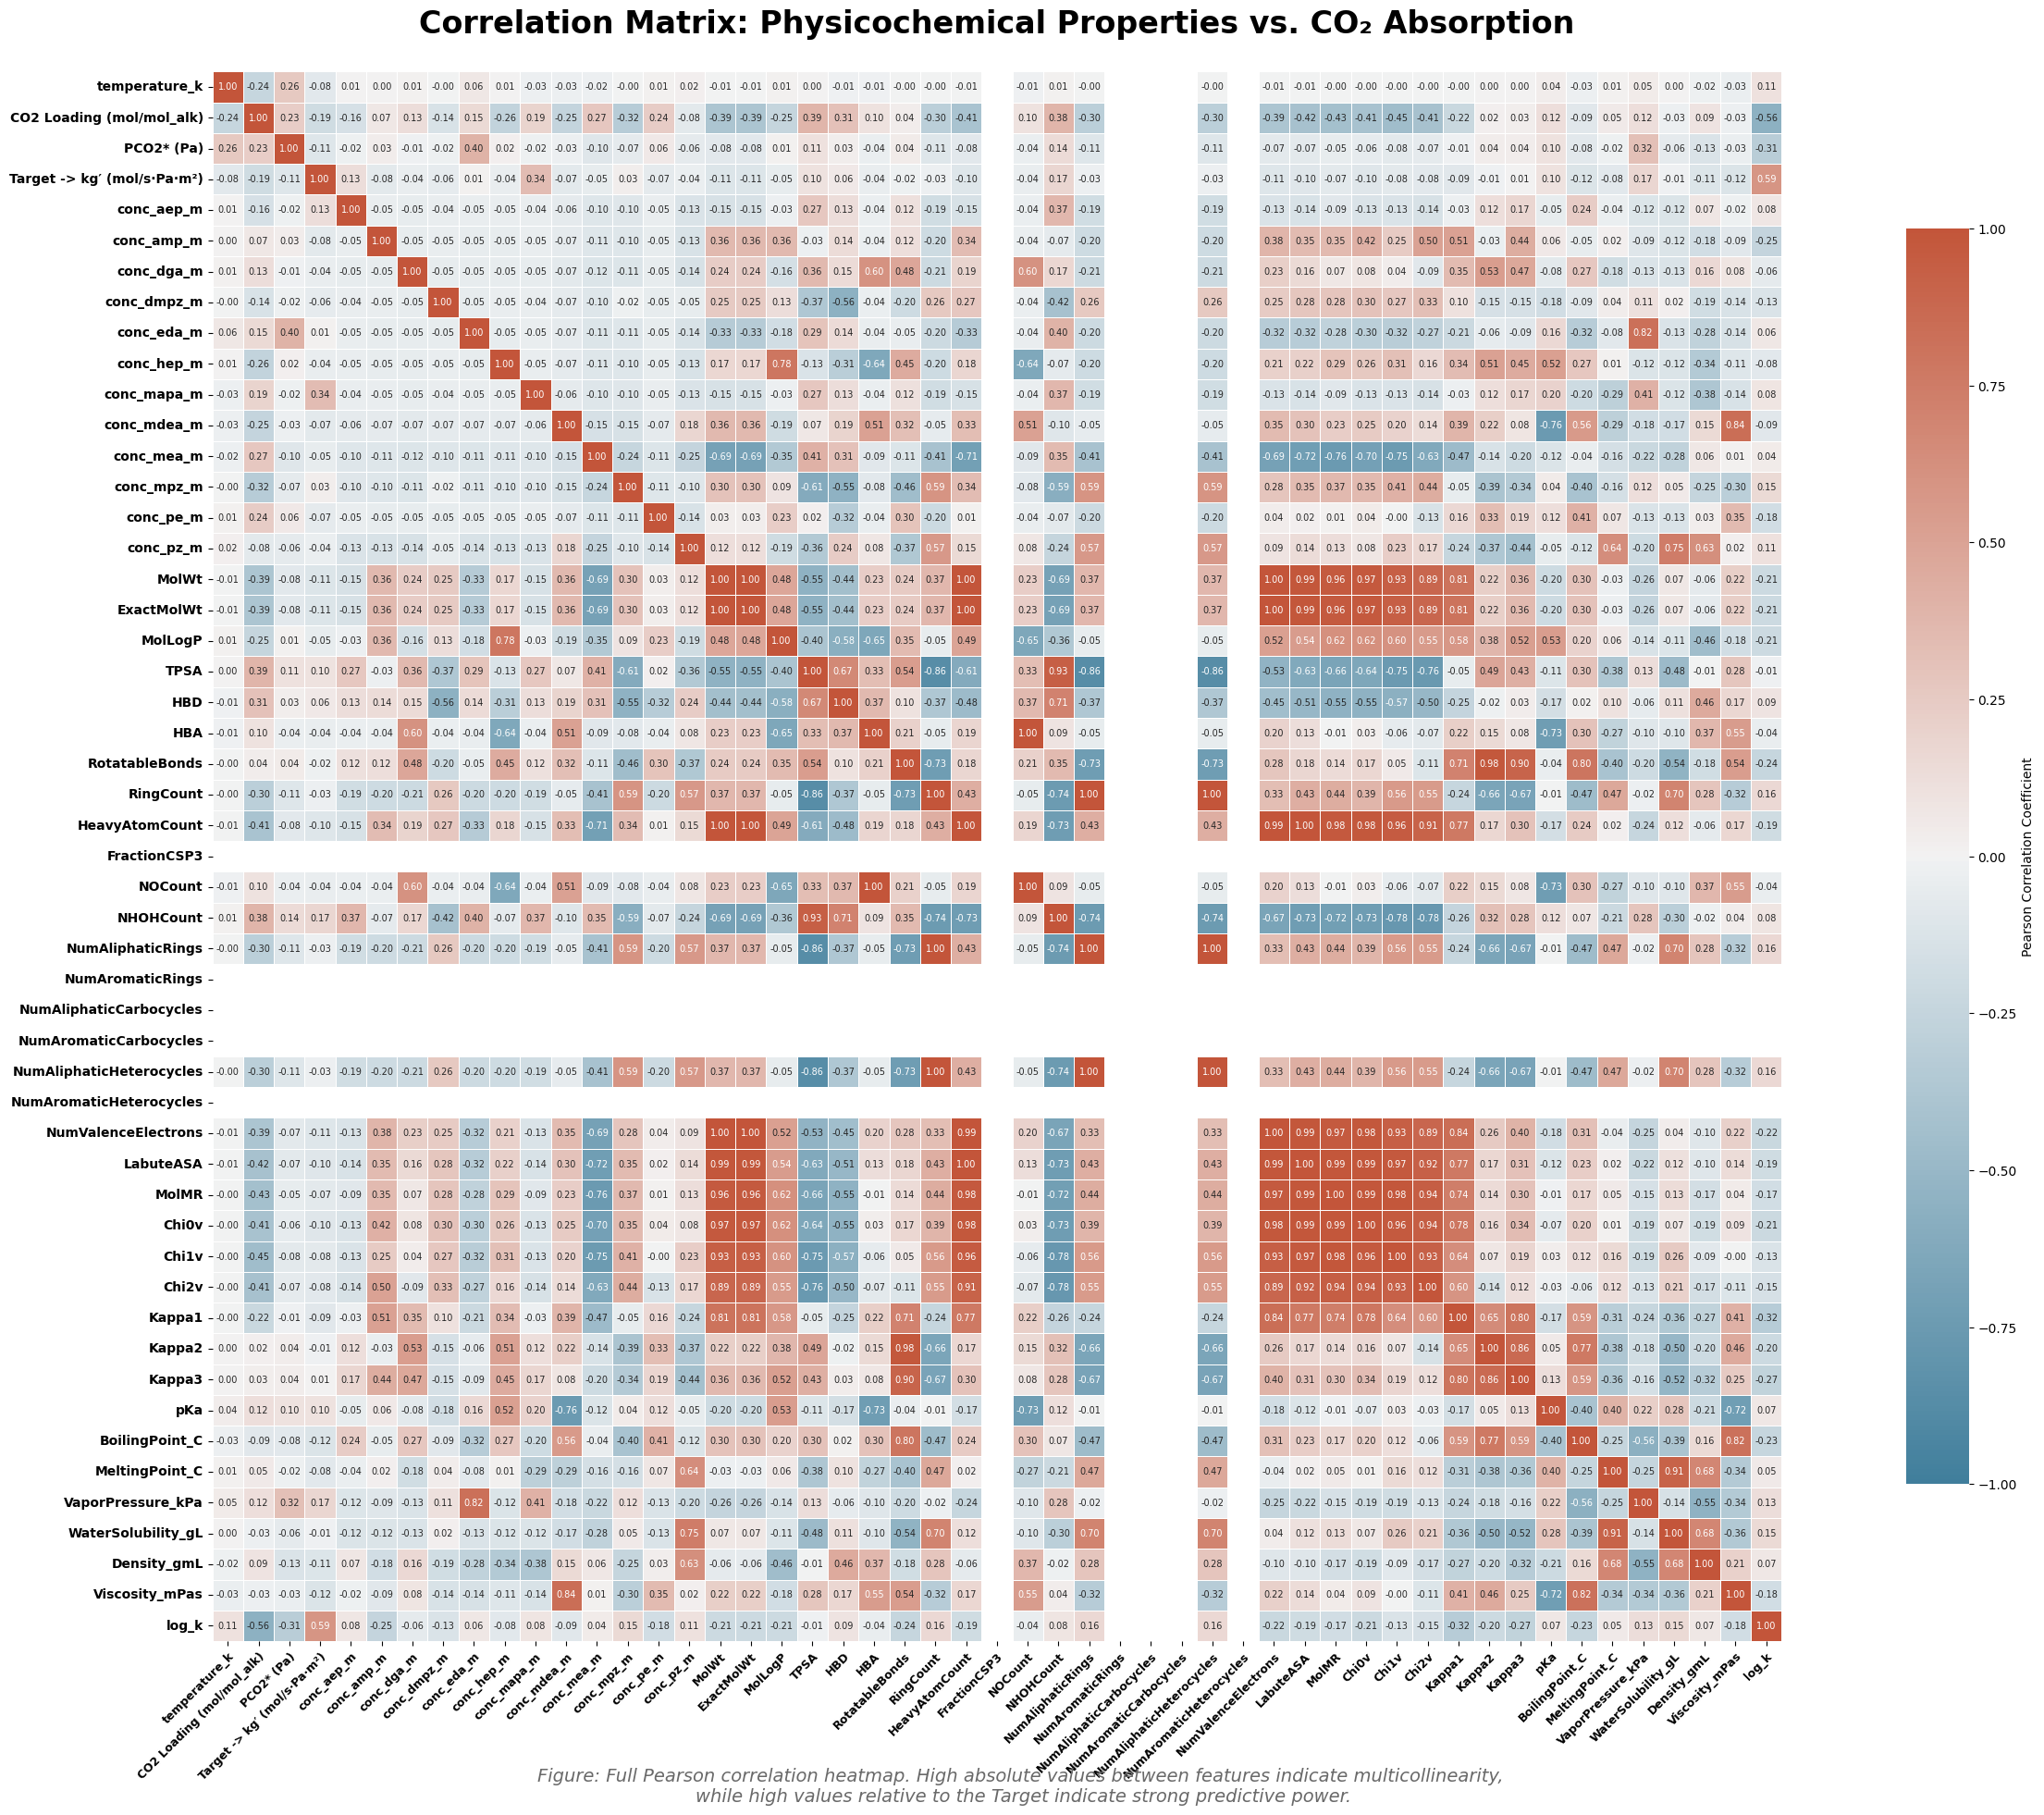

In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS: FULL CORRELATION MATRIX
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Clean Full Correlation Matrix...")

# 1. Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# 3. Increased width to 28 to give the columns more horizontal space
plt.figure(figsize=(28, 20))

# 4. Professional diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 5. Generate the heatmap
ax = sns.heatmap(
    corr_matrix,
    cmap=cmap,
    vmax=1.0, vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}  # Reduced text size inside the boxes
)

# 6. THE FIX: Aggressive X-axis formatting
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',              # Align right
    rotation_mode='anchor',  # Forces the rotation to pivot exactly at the tick mark!
    fontsize=9,              # Shrunk font size to prevent horizontal crashing
    weight='bold'            # Made bold to keep it readable despite being smaller
)

# Clean up Y-axis labels
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
    weight='bold'
)

plt.title('Correlation Matrix: Physicochemical Properties vs. CO₂ Absorption',
          fontsize=24, weight='bold', pad=30)

plt.figtext(0.5, 0.01,
            "Figure: Full Pearson correlation heatmap. High absolute values between features indicate multicollinearity, \nwhile high values relative to the Target indicate strong predictive power.",
            ha='center', fontsize=14, style='italic', color='dimgrey')

# Added padding to tight_layout so the long angled labels don't get cut off at the bottom
plt.tight_layout(pad=3.0)
plt.show()

Generating Classic Full Correlation Matrix for Top 10 Features...



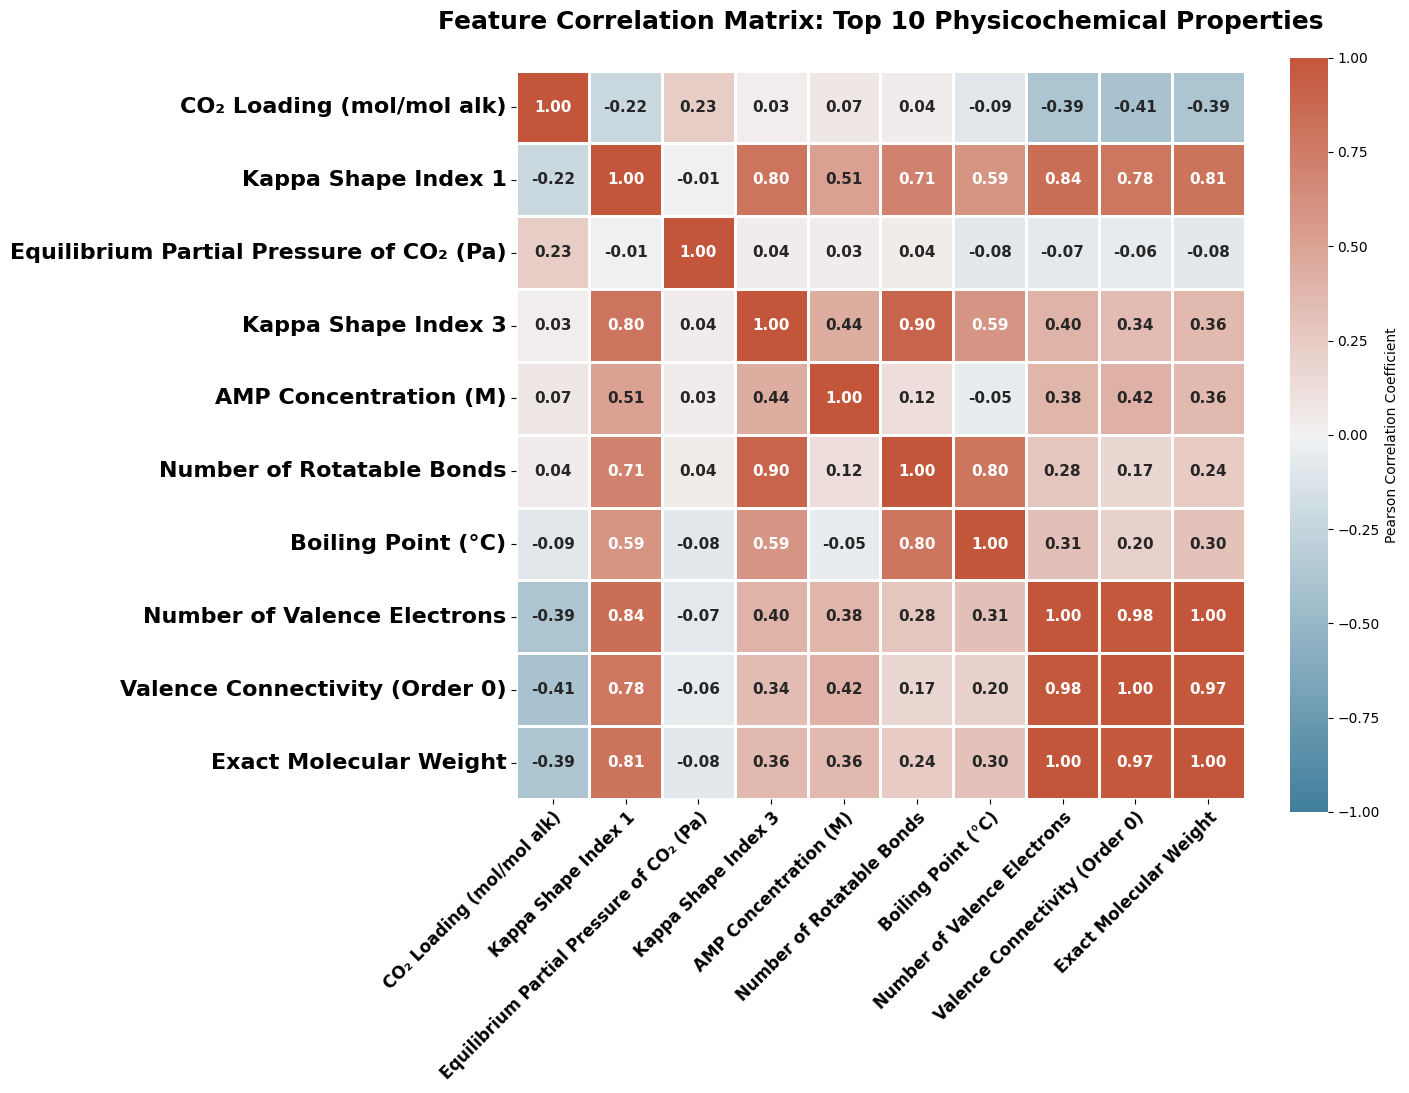

In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS: CLEAN TOP 10 FEATURES MATRIX
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Classic Full Correlation Matrix for Top 10 Features...\n")

# 1. Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Get absolute correlations with the target ('log_k')
all_correlations = numeric_df.corr()['log_k'].abs()

# 3. Drop target columns
targets_to_drop = ['log_k', 'Target -> kg′ (mol/s·Pa·m²)']
targets_to_drop = [t for t in targets_to_drop if t in all_correlations.index]

feature_correlations = all_correlations.drop(labels=targets_to_drop)

# 4. Get Top 10 features
top_10_features = feature_correlations.sort_values(ascending=False).head(10).index

# 5. Correlation matrix
top_corr_matrix = numeric_df[top_10_features].corr()

# ============================================================
# Feature Name Mapping
# ============================================================

feature_mapping = {

    # ---------------- Process Variables ----------------
    'TEMPERATURE_K': 'Temperature (K)',
    'CO2 LOADING (MOL/MOL_ALK)': 'CO₂ Loading (mol/mol alk)',
    'PCO2* (PA)': 'Equilibrium Partial Pressure of CO₂ (Pa)',

    # ---------------- Concentrations ----------------
    'CONC_AEP_M': 'AEP Concentration (M)',
    'CONC_AMP_M': 'AMP Concentration (M)',
    'CONC_DGA_M': 'DGA Concentration (M)',
    'CONC_DMPZ_M': 'DMPZ Concentration (M)',
    'CONC_EDA_M': 'EDA Concentration (M)',
    'CONC_HEP_M': 'HEP Concentration (M)',
    'CONC_MAPA_M': 'MAPA Concentration (M)',
    'CONC_MDEA_M': 'MDEA Concentration (M)',
    'CONC_MEA_M': 'MEA Concentration (M)',
    'CONC_MPZ_M': 'MPZ Concentration (M)',
    'CONC_PE_M': 'PE Concentration (M)',
    'CONC_PZ_M': 'PZ Concentration (M)',

    # ---------------- Molecular Properties ----------------
    'MOLWT': 'Molecular Weight',
    'EXACTMOLWT': 'Exact Molecular Weight',
    'MOLLOGP': 'LogP (Partition Coefficient)',
    'TPSA': 'Topological Polar Surface Area',
    'MOLMR': 'Molar Refractivity',

    # ---------------- Hydrogen Bonding ----------------
    'HBD': 'Number of H-Bond Donors',
    'HBA': 'Number of H-Bond Acceptors',

    # ---------------- Structural Descriptors ----------------
    'ROTATABLEBONDS': 'Number of Rotatable Bonds',
    'RINGCOUNT': 'Ring Count',
    'HEAVYATOMCOUNT': 'Heavy Atom Count',
    'FRACTIONCSP3': 'Fraction of sp³ Carbons',
    'NUMVALENCEELECTRONS': 'Number of Valence Electrons',

    # ---------------- Connectivity Indices ----------------
    'CHI0V': 'Valence Connectivity (Order 0)',
    'CHI1V': 'Valence Connectivity (Order 1)',
    'CHI2V': 'Valence Connectivity (Order 2)',

    # ---------------- Shape Indices ----------------
    'KAPPA1': 'Kappa Shape Index 1',
    'KAPPA2': 'Kappa Shape Index 2',
    'KAPPA3': 'Kappa Shape Index 3',

    # ---------------- Other Descriptors ----------------
    'LABUTEASA': 'Labute Surface Area',
    'NOCOUNT': 'Nitrogen-Oxygen Count',
    'NHOHCOUNT': 'NHOH Group Count',

    'NUMALIPHATICRINGS': 'Aliphatic Ring Count',
    'NUMAROMATICRINGS': 'Aromatic Ring Count',
    'NUMALIPHATICCARBOCYCLES': 'Aliphatic Carbocycle Count',
    'NUMAROMATICCARBOCYCLES': 'Aromatic Carbocycle Count',
    'NUMALIPHATICHETEROCYCLES': 'Aliphatic Heterocycle Count',
    'NUMAROMATICHETEROCYCLES': 'Aromatic Heterocycle Count',

    'PKA': 'pKa',
    'BOILINGPOINT_C': 'Boiling Point (°C)',
    'MELTINGPOINT_C': 'Melting Point (°C)',
    'VAPORPRESSURE_KPA': 'Vapor Pressure (kPa)',
    'WATERSOLUBILITY_GL': 'Water Solubility (g/L)',
    'DENSITY_GML': 'Density (g/mL)',
    'VISCOSITY_MPAS': 'Viscosity (mPa·s)'
}


def clean_feature_name(name):
    """
    Convert raw feature names into publication-quality labels.
    """
    name = str(name).strip()
    key = name.upper()

    # Exact mapping
    if key in feature_mapping:
        return feature_mapping[key]

    # Catch any pCO2 variants
    if "PCO2" in key:
        return "Equilibrium Partial Pressure of CO₂ (Pa)"

    # Better default formatting
    cleaned = (
        name.replace('_', ' ')
            .replace('CO2', 'CO₂')
            .replace('CSP3', 'sp³')
            .replace('MolWt', 'Molecular Weight')
            .replace('ExactMolWt', 'Exact Molecular Weight')
            .title()
    )

    return cleaned


# Apply cleaned names
top_corr_matrix.index = [clean_feature_name(col) for col in top_corr_matrix.index]
top_corr_matrix.columns = [clean_feature_name(col) for col in top_corr_matrix.columns]

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(15, 13))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

ax = sns.heatmap(
    top_corr_matrix,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=1.0,
    annot=True,
    fmt=".2f",
    annot_kws={"size":11, "weight":"bold"},
    cbar_kws={
        "shrink":0.8,
        "label":"Pearson Correlation Coefficient"
    }
)

# Axis formatting
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    rotation_mode='anchor',
    fontsize=12,
    weight='bold'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=16,
    weight='bold'
)

plt.title(
    "Feature Correlation Matrix: Top 10 Physicochemical Properties",
    fontsize=18,
    weight='bold',
    pad=30
)


plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(696, 49)
(174, 49)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    'RSM (Polynomial Regression)': LinearRegression(),

    'SVM': SVR(
        kernel='rbf',
        C=10,
        gamma='scale'
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ),

    'MLP (1 Layer)': MLPRegressor(
        hidden_layer_sizes=(64,),
        max_iter=1000,
        random_state=42
    ),

    'MLP (2 Layer)': MLPRegressor(
        hidden_layer_sizes=(128,64),
        max_iter=1000,
        random_state=42
    ),

    'MLP (3 Layer)': MLPRegressor(
        hidden_layer_sizes=(256,128,64),
        max_iter=1000,
        random_state=42
    ),

    # Additional Models

    'Ridge Regression': Ridge(alpha=1.0),

    'Lasso Regression': Lasso(alpha=0.001),

    'Decision Tree': DecisionTreeRegressor(
        random_state=42
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=300,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

In [ ]:
# Check missing values

missing = X.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [ ]:
results = []

for name, model in models.items():

    print(f'Training {name}...')

    # Neural nets + SVM use scaled data
    if 'MLP' in name or name == 'SVM' or name == 'KNN':

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    mae = mean_absolute_error(y_test, pred)

    results.append([
        name,
        r2,
        rmse,
        mae
    ])

Training RSM (Polynomial Regression)...
Training SVM...
Training Random Forest...
Training XGBoost...
Training MLP (1 Layer)...
Training MLP (2 Layer)...
Training MLP (3 Layer)...
Training Ridge Regression...
Training Lasso Regression...
Training Decision Tree...
Training Extra Trees...
Training Gradient Boosting...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1069
[LightGBM] [Info] Number of data points in the train set: 696, number of used features: 44
[LightGBM] [Info] Start training from score -5.895040
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'R2', 'RMSE', 'MAE']
)

results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

results_df

,Model,R2,RMSE,MAE
10,Extra Trees,0.993638,0.037098,0.019264
3,XGBoost,0.988570,0.049724,0.031632
12,LightGBM,0.976920,0.070658,0.045872
2,Random Forest,0.968854,0.082082,0.050364
11,Gradient Boosting,0.965114,0.086871,0.067937
9,Decision Tree,0.958941,0.094243,0.027020
6,MLP (3 Layer),0.925837,0.126660,0.082368
5,MLP (2 Layer),0.922107,0.129806,0.087121
1,SVM,0.917708,0.133421,0.083313
4,MLP (1 Layer),0.888094,0.155587,0.108093


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=42
    ),
    X,
    y,
    cv=kf,
    scoring='r2'
)

print(scores)
print(scores.mean())
print(scores.std())

[0.99427145 0.9953305  0.99701933 0.98546051 0.99339712]
0.9930957820332
0.004003962210609457


In [ ]:
high_corr = X.corrwith(y).abs().sort_values(
    ascending=False
)

print(high_corr.head(15))

CO2 Loading (mol/mol_alk)    0.561336
Kappa1                       0.321024
PCO2* (Pa)                   0.314234
Kappa3                       0.267181
conc_amp_m                   0.253192
RotatableBonds               0.238758
BoilingPoint_C               0.234712
NumValenceElectrons          0.219769
Chi0v                        0.211082
ExactMolWt                   0.209991
MolWt                        0.209979
MolLogP                      0.208772
Kappa2                       0.203419
LabuteASA                    0.190679
HeavyAtomCount               0.190377
dtype: float64


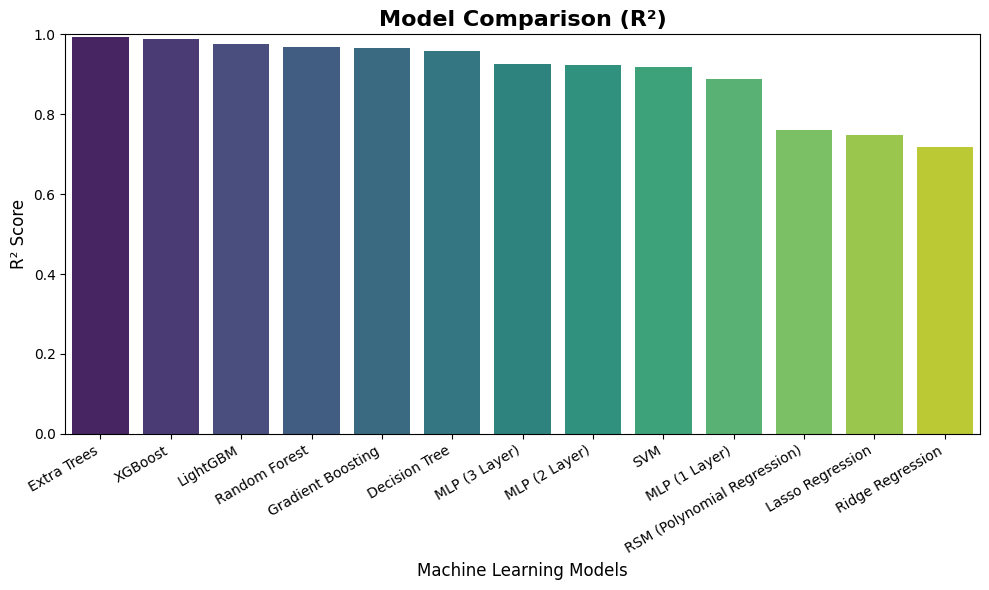

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2',
    palette='viridis'
)

plt.title('Model Comparison (R²)', fontsize=16, weight='bold')
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('R² Score', fontsize=12)

plt.ylim(0, 1)

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

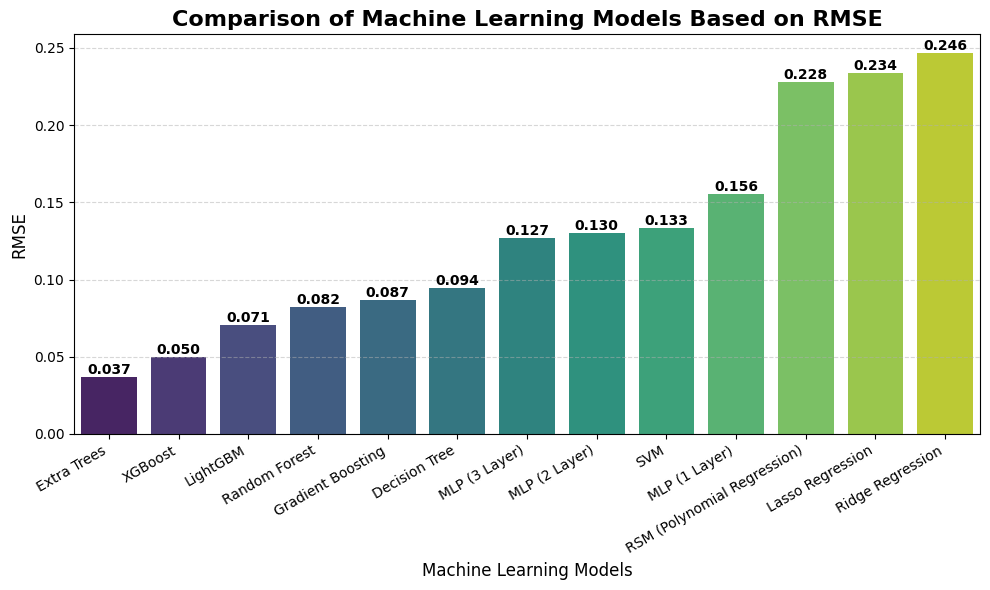

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE',
    palette='viridis'
)

# Annotate bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Comparison of Machine Learning Models Based on RMSE',
          fontsize=16, weight='bold')
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('RMSE', fontsize=12)

plt.xticks(rotation=30, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

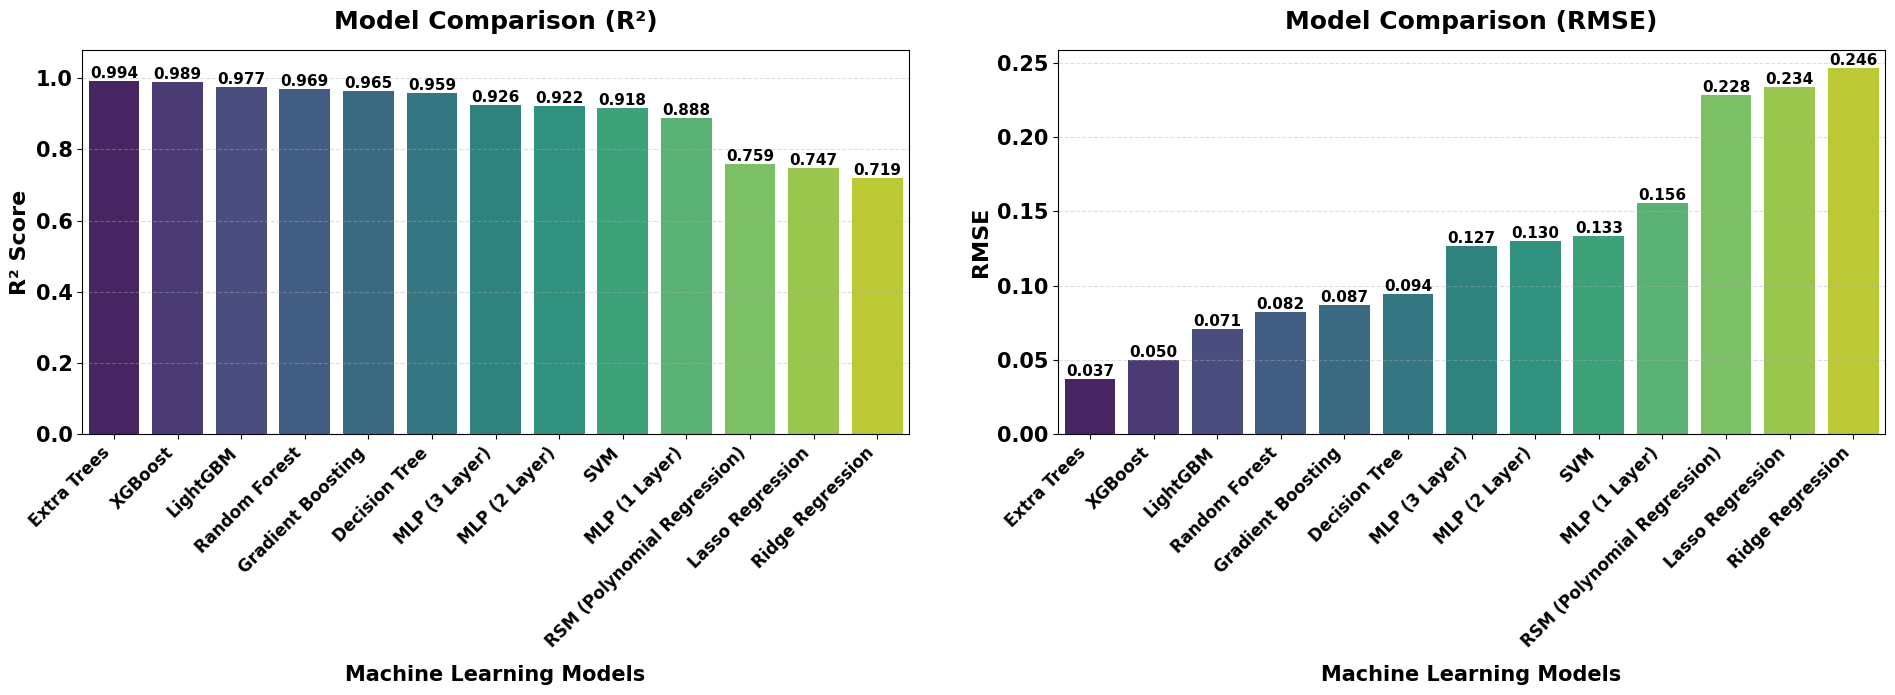

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.size': 15,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ============================================================
# R² Plot
# ============================================================

sns.barplot(data=results_df, x='Model', y='R2', palette='viridis', ax=axes[0])

for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

axes[0].set_title("Model Comparison (R²)", fontsize=18, fontweight='bold', pad=15)
axes[0].set_xlabel("Machine Learning Models", fontsize=15, fontweight='bold', labelpad=10)
axes[0].set_ylabel("R² Score", fontsize=16, fontweight='bold')
axes[0].set_ylim(0, 1.08)

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45, ha='right', fontsize=12, fontweight='bold'
)
for label in axes[0].get_yticklabels():
    label.set_fontweight('bold')

axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# ============================================================
# RMSE Plot
# ============================================================

sns.barplot(data=results_df, x='Model', y='RMSE', palette='viridis', ax=axes[1])

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

axes[1].set_title("Model Comparison (RMSE)", fontsize=18, fontweight='bold', pad=15)
axes[1].set_xlabel("Machine Learning Models", fontsize=15, fontweight='bold', labelpad=10)
axes[1].set_ylabel("RMSE", fontsize=16, fontweight='bold')

axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=45, ha='right', fontsize=12, fontweight='bold'
)
for label in axes[1].get_yticklabels():
    label.set_fontweight('bold')

axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# ============================================================
# Layout
# ============================================================

plt.tight_layout(pad=3.0)

# plt.savefig("Model_Comparison_R2_RMSE.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]['Model']

best_model = models[best_model_name]

print(best_model_name)

Extra Trees


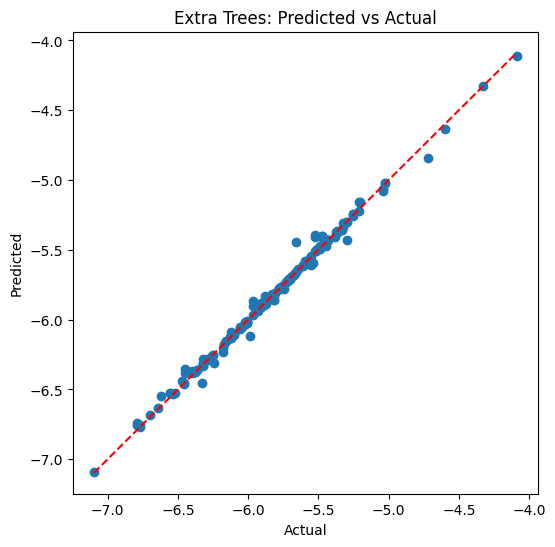

In [ ]:
if 'MLP' in best_model_name or best_model_name == 'SVM' or best_model_name == 'KNN':

    pred = best_model.predict(X_test_scaled)

else:

    pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.title(f'{best_model_name}: Predicted vs Actual')

plt.show()

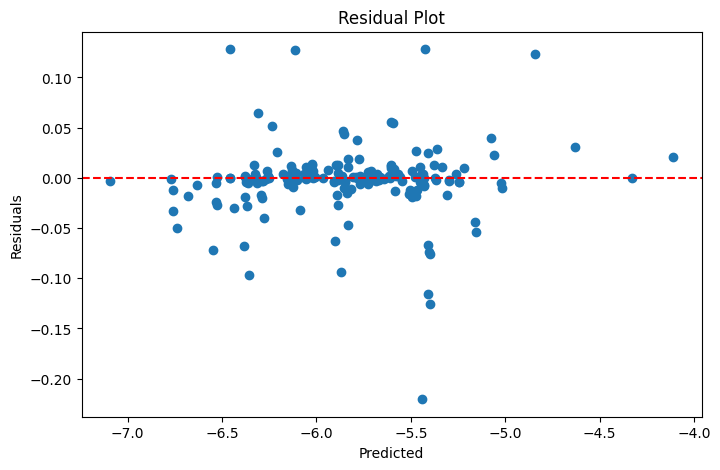

In [ ]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted')
plt.ylabel('Residuals')

plt.title('Residual Plot')

plt.show()

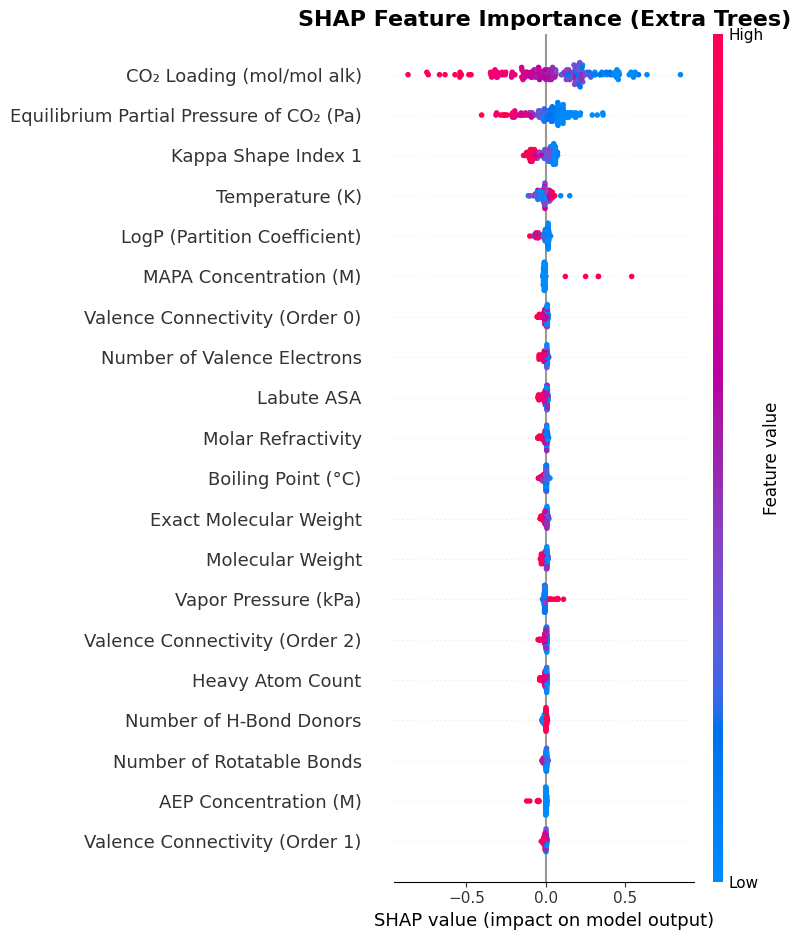

In [ ]:
# ============================================================
# SHAP Summary Plot (Publication Quality)
# ============================================================

import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Function to clean feature names
# ------------------------------------------------------------
feature_mapping = {
    'TEMPERATURE_K': 'Temperature (K)',
    'CO2 LOADING (MOL/MOL_ALK)': 'CO₂ Loading (mol/mol alk)',
    'PCO2* (PA)': 'Equilibrium Partial Pressure of CO₂ (Pa)',

    'CONC_AEP_M': 'AEP Concentration (M)',
    'CONC_AMP_M': 'AMP Concentration (M)',
    'CONC_DGA_M': 'DGA Concentration (M)',
    'CONC_DMPZ_M': 'DMPZ Concentration (M)',
    'CONC_EDA_M': 'EDA Concentration (M)',
    'CONC_HEP_M': 'HEP Concentration (M)',
    'CONC_MAPA_M': 'MAPA Concentration (M)',
    'CONC_MDEA_M': 'MDEA Concentration (M)',
    'CONC_MEA_M': 'MEA Concentration (M)',
    'CONC_MPZ_M': 'MPZ Concentration (M)',
    'CONC_PE_M': 'PE Concentration (M)',
    'CONC_PZ_M': 'PZ Concentration (M)',

    'MOLWT': 'Molecular Weight',
    'EXACTMOLWT': 'Exact Molecular Weight',
    'MOLLOGP': 'LogP (Partition Coefficient)',
    'TPSA': 'Topological Polar Surface Area',
    'MOLMR': 'Molar Refractivity',

    'HBD': 'Number of H-Bond Donors',
    'HBA': 'Number of H-Bond Acceptors',

    'ROTATABLEBONDS': 'Number of Rotatable Bonds',
    'RINGCOUNT': 'Ring Count',
    'HEAVYATOMCOUNT': 'Heavy Atom Count',
    'FRACTIONCSP3': 'Fraction of sp³ Carbons',
    'NUMVALENCEELECTRONS': 'Number of Valence Electrons',

    'CHI0V': 'Valence Connectivity (Order 0)',
    'CHI1V': 'Valence Connectivity (Order 1)',
    'CHI2V': 'Valence Connectivity (Order 2)',

    'KAPPA1': 'Kappa Shape Index 1',
    'KAPPA2': 'Kappa Shape Index 2',
    'KAPPA3': 'Kappa Shape Index 3',

    'PKA': 'pKa',
    'LABUTEASA': 'Labute ASA',
    'BOILINGPOINT_C': 'Boiling Point (°C)',
    'MELTINGPOINT_C': 'Melting Point (°C)',
    'VAPORPRESSURE_KPA': 'Vapor Pressure (kPa)',
    'WATERSOLUBILITY_GL': 'Water Solubility (g/L)',
    'DENSITY_GML': 'Density (g/mL)',
    'VISCOSITY_MPAS': 'Viscosity (mPa·s)'
}

def clean_feature_name(name):
    key = str(name).strip().upper()

    if key in feature_mapping:
        return feature_mapping[key]

    if "PCO2" in key:
        return "Equilibrium Partial Pressure of CO₂ (Pa)"

    return (
        str(name)
        .replace("_", " ")
        .replace("CO2", "CO₂")
        .title()
    )


# ------------------------------------------------------------
# SHAP
# ------------------------------------------------------------

if best_model_name in [
    'Random Forest',
    'Extra Trees',
    'Gradient Boosting',
    'XGBoost',
    'LightGBM',
    'CatBoost'
]:

    # Create a renamed copy of X_test
    X_test_display = X_test.copy()
    X_test_display.columns = [
        clean_feature_name(col)
        for col in X_test.columns
    ]

    # Build explainer on original model
    explainer = shap.Explainer(best_model)

    # Compute SHAP values using ORIGINAL data
    shap_values = explainer(X_test)

    # Create a new Explanation object with renamed feature names
    shap_values = shap.Explanation(
        values=shap_values.values,
        base_values=shap_values.base_values,
        data=X_test_display.values,
        feature_names=X_test_display.columns.tolist()
    )

    plt.figure(figsize=(12, 8))

    shap.summary_plot(
        shap_values,
        show=False,
        max_display=20
    )

    plt.title(
        f"SHAP Feature Importance ({best_model_name})",
        fontsize=16,
        weight='bold'
    )

    plt.tight_layout()
    plt.show()

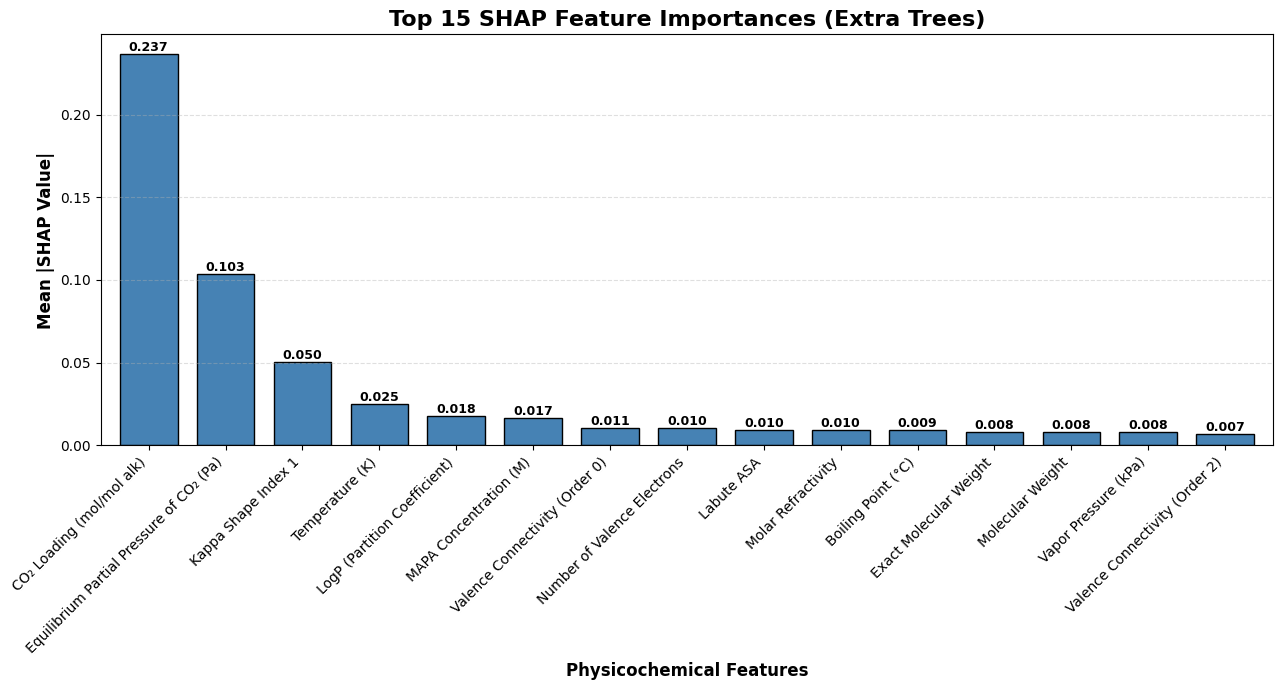

,Mean |SHAP Value|
CO₂ Loading (mol/mol alk),0.236619
Equilibrium Partial Pressure of CO₂ (Pa),0.103318
Kappa Shape Index 1,0.050336
Temperature (K),0.025287
LogP (Partition Coefficient),0.017962
MAPA Concentration (M),0.016750
Valence Connectivity (Order 0),0.010647
Number of Valence Electrons,0.010285
Labute ASA,0.009609
Molar Refractivity,0.009596


In [ ]:
# ============================================================
# SHAP FEATURE IMPORTANCE (Top 15 Features)
# ============================================================

if best_model_name in [
    'Random Forest',
    'Extra Trees',
    'Gradient Boosting',
    'XGBoost',
    'LightGBM'
]:

    # Mean absolute SHAP importance
    shap_importance = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=False)

    # Keep top 15 and rename features
    top15 = shap_importance.head(15).copy()
    top15.index = [clean_feature_name(col) for col in top15.index]

    # Plot
    plt.figure(figsize=(13, 7))

    ax = top15.plot(
        kind='bar',
        color='steelblue',
        edgecolor='black',
        width=0.75
    )

    # Annotate bars
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    plt.xlabel('Physicochemical Features', fontsize=12, weight='bold')
    plt.ylabel('Mean |SHAP Value|', fontsize=12, weight='bold')

    plt.title(
        f'Top 15 SHAP Feature Importances ({best_model_name})',
        fontsize=16,
        weight='bold'
    )

    plt.xticks(rotation=45, ha='right', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()

    plt.show()

    # Display table with clean names
    display(
        top15.rename("Mean |SHAP Value|").to_frame()
    )

# ============================================================
# IMPACT OF ADDING PHYSICOCHEMICAL FEATURES
# ============================================================

print("""
COMPARISON OF MODEL PERFORMANCE:
ORIGINAL DATASET vs UPDATED DATASET

The updated dataset included additional physicochemical
properties such as:

- pKa
- Boiling Point
- Melting Point
- Vapor Pressure
- Density
- Water Solubility
- Viscosity

These features introduced thermodynamic, transport,
and acid-base behavior into the machine learning pipeline,
making the model more chemically informed.

------------------------------------------------------------
OBSERVED CHANGES AFTER FEATURE ADDITION
------------------------------------------------------------

1. IMPROVED MODEL PERFORMANCE

Tree-based ensemble models showed noticeable improvement
after adding physicochemical properties.

Earlier:
- XGBoost was the best model
- Molecular descriptors had weaker influence

Now:
- Extra Trees achieved the highest performance
- Cross-validation R² ≈ 0.993
- Model stability improved significantly

This indicates that the new physicochemical properties
provided additional chemically meaningful information.

------------------------------------------------------------

2. STRONGER MOLECULAR CONTRIBUTIONS

Previously, process variables such as:
- CO₂ Loading
- PCO₂*
- Temperature

dominated the model predictions.

After adding new properties:
- Kappa descriptors became more important
- Boiling Point appeared in top SHAP features
- Vapor Pressure contributed to predictions
- Molecular structure-property relationships became stronger

This shows that the model now captures both:
- process-level effects
- molecular-level behavior

------------------------------------------------------------

3. BETTER PHYSICAL INTERPRETABILITY

The updated SHAP analysis showed physically meaningful trends:

- Higher CO₂ loading suppresses absorption
- Lower equilibrium pressure increases driving force
- Cyclic descriptors (Kappa1) influence kinetics
- Thermodynamic properties affect solvent behavior

This improved the scientific credibility of the model.

------------------------------------------------------------

4. MODEL BEHAVIOR

Linear and polynomial models:
- Ridge
- Lasso
- RSM

still underperformed compared to ensemble models.

This confirms that:
the CO₂ absorption system is highly nonlinear and
cannot be represented adequately using simple equations.

------------------------------------------------------------

5. FINAL CONCLUSION

Adding physicochemical properties transformed the model from:

    descriptor-based regression

into:

    chemically informed, physics-aware machine learning

The updated dataset produced:
- better generalization
- improved interpretability
- stronger chemistry relevance
- more reliable screening capability

Overall, the new features significantly improved the
quality and scientific value of the project.
""")

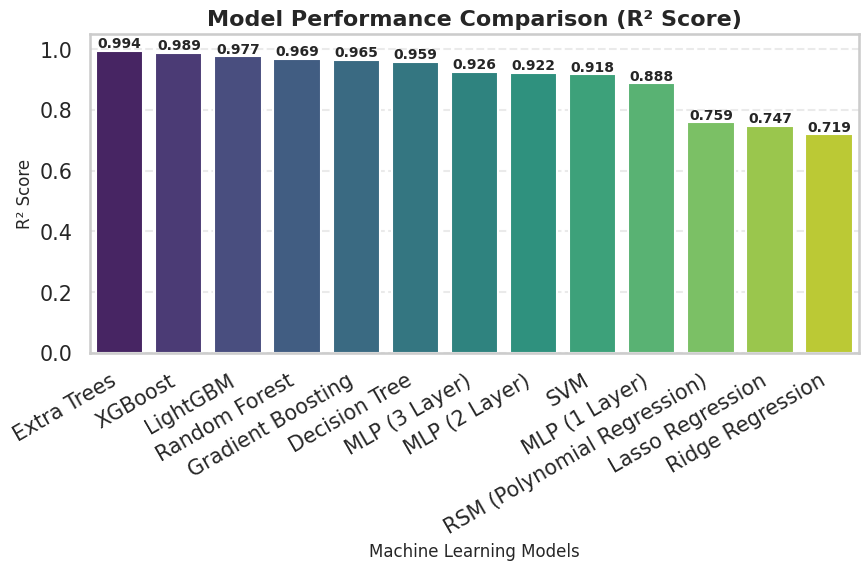

In [ ]:
# ============================================================
# FIGURE 1: MODEL PERFORMANCE COMPARISON (R²)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=results_df.sort_values('R2', ascending=False),
    x='Model',
    y='R2',
    palette='viridis'
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Model Performance Comparison (R² Score)',
          fontsize=16, weight='bold')

plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('R² Score', fontsize=12)

plt.ylim(0, 1.05)

plt.xticks(rotation=30, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

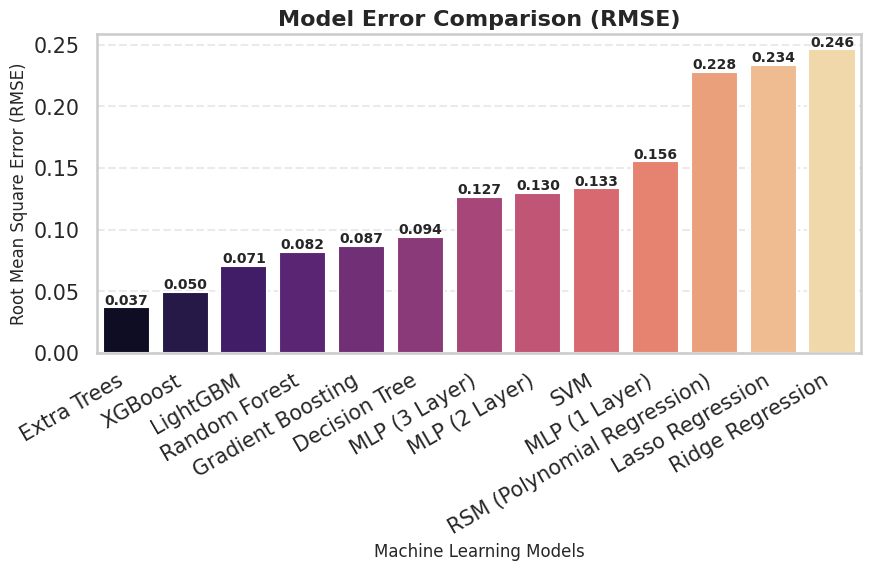

In [ ]:
# ============================================================
# FIGURE 2: MODEL PERFORMANCE COMPARISON (RMSE)
# ============================================================

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=results_df.sort_values('RMSE'),
    x='Model',
    y='RMSE',
    palette='magma'
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Model Error Comparison (RMSE)',
          fontsize=16,
          weight='bold')

plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Root Mean Square Error (RMSE)', fontsize=12)

plt.xticks(rotation=30, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

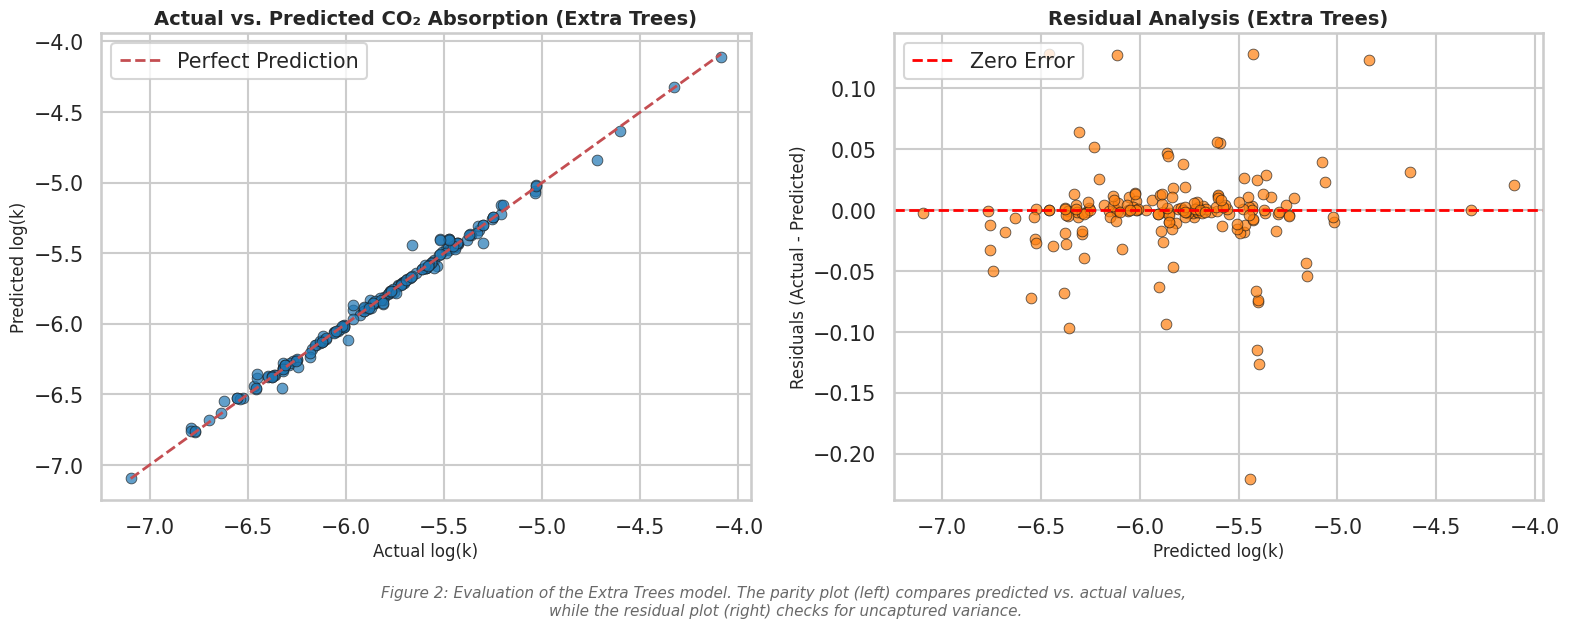

In [ ]:
# ============================================================
# 2. ENHANCED ACTUAL VS PREDICTED & RESIDUALS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sns.scatterplot(x=y_test, y=pred, ax=axes[0], alpha=0.7, color='#1f77b4', s=60, edgecolor='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs. Predicted CO₂ Absorption ({best_model_name})', fontsize=14, weight='bold')
axes[0].set_xlabel('Actual log(k)', fontsize=12)
axes[0].set_ylabel('Predicted log(k)', fontsize=12)
axes[0].legend(loc='upper left')

# Residuals
residuals = y_test - pred
sns.scatterplot(x=pred, y=residuals, ax=axes[1], alpha=0.7, color='#ff7f0e', s=60, edgecolor='k')
axes[1].axhline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[1].set_title(f'Residual Analysis ({best_model_name})', fontsize=14, weight='bold')
axes[1].set_xlabel('Predicted log(k)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].legend(loc='upper left')

# Caption
fig.text(0.5, -0.05,
         f"Figure 2: Evaluation of the {best_model_name} model. The parity plot (left) compares predicted vs. actual values, \nwhile the residual plot (right) checks for uncaptured variance.",
         ha='center', fontsize=11, style='italic', color='dimgrey')

plt.tight_layout()
plt.show()

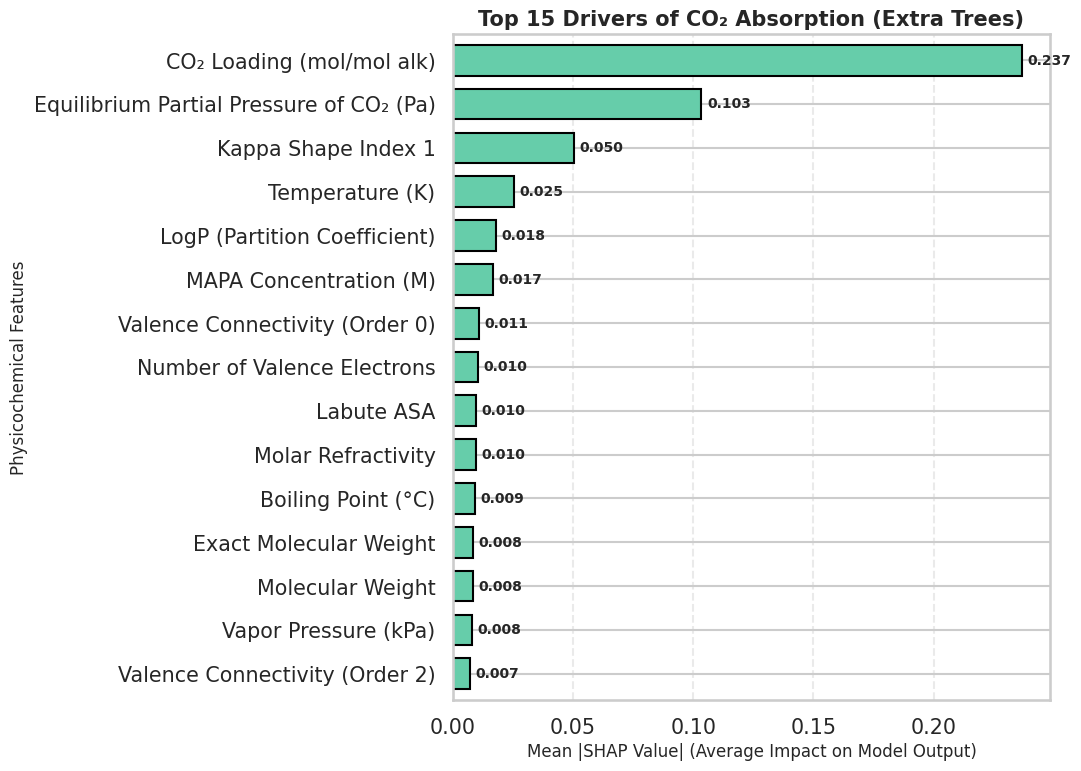

,Mean |SHAP Value|
Valence Connectivity (Order 2),0.007112
Vapor Pressure (kPa),0.007903
Molecular Weight,0.008216
Exact Molecular Weight,0.008293
Boiling Point (°C),0.009111
Molar Refractivity,0.009596
Labute ASA,0.009609
Number of Valence Electrons,0.010285
Valence Connectivity (Order 0),0.010647
MAPA Concentration (M),0.016750


In [ ]:
# ============================================================
# 3. ENHANCED SHAP FEATURE IMPORTANCE
# ============================================================

if best_model_name in [
    'Random Forest',
    'Extra Trees',
    'Gradient Boosting',
    'XGBoost',
    'LightGBM',
    'CatBoost'
]:

    plt.figure(figsize=(11, 8))

    # Calculate Mean Absolute SHAP values
    shap_importance = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=True)

    # Select Top 15 Features
    top_15_shap = shap_importance.tail(15).copy()

    # Replace raw feature names with publication-quality names
    top_15_shap.index = [
        clean_feature_name(feature)
        for feature in top_15_shap.index
    ]

    # Plot
    ax = top_15_shap.plot(
        kind='barh',
        color='mediumaquamarine',
        edgecolor='black',
        width=0.7
    )

    plt.title(
        f'Top 15 Drivers of CO₂ Absorption ({best_model_name})',
        fontsize=15,
        weight='bold'
    )

    plt.xlabel(
        'Mean |SHAP Value| (Average Impact on Model Output)',
        fontsize=12
    )

    plt.ylabel(
        'Physicochemical Features',
        fontsize=12
    )

    # Add value labels
    for i, v in enumerate(top_15_shap):
        ax.text(
            v + (top_15_shap.max() * 0.01),
            i,
            f'{v:.3f}',
            va='center',
            fontsize=10,
            weight='bold'
        )

    plt.grid(axis='x', linestyle='--', alpha=0.4)


    plt.tight_layout()
    plt.show()

    # Display table with clean feature names
    display(
        top_15_shap.rename("Mean |SHAP Value|").to_frame()
    )

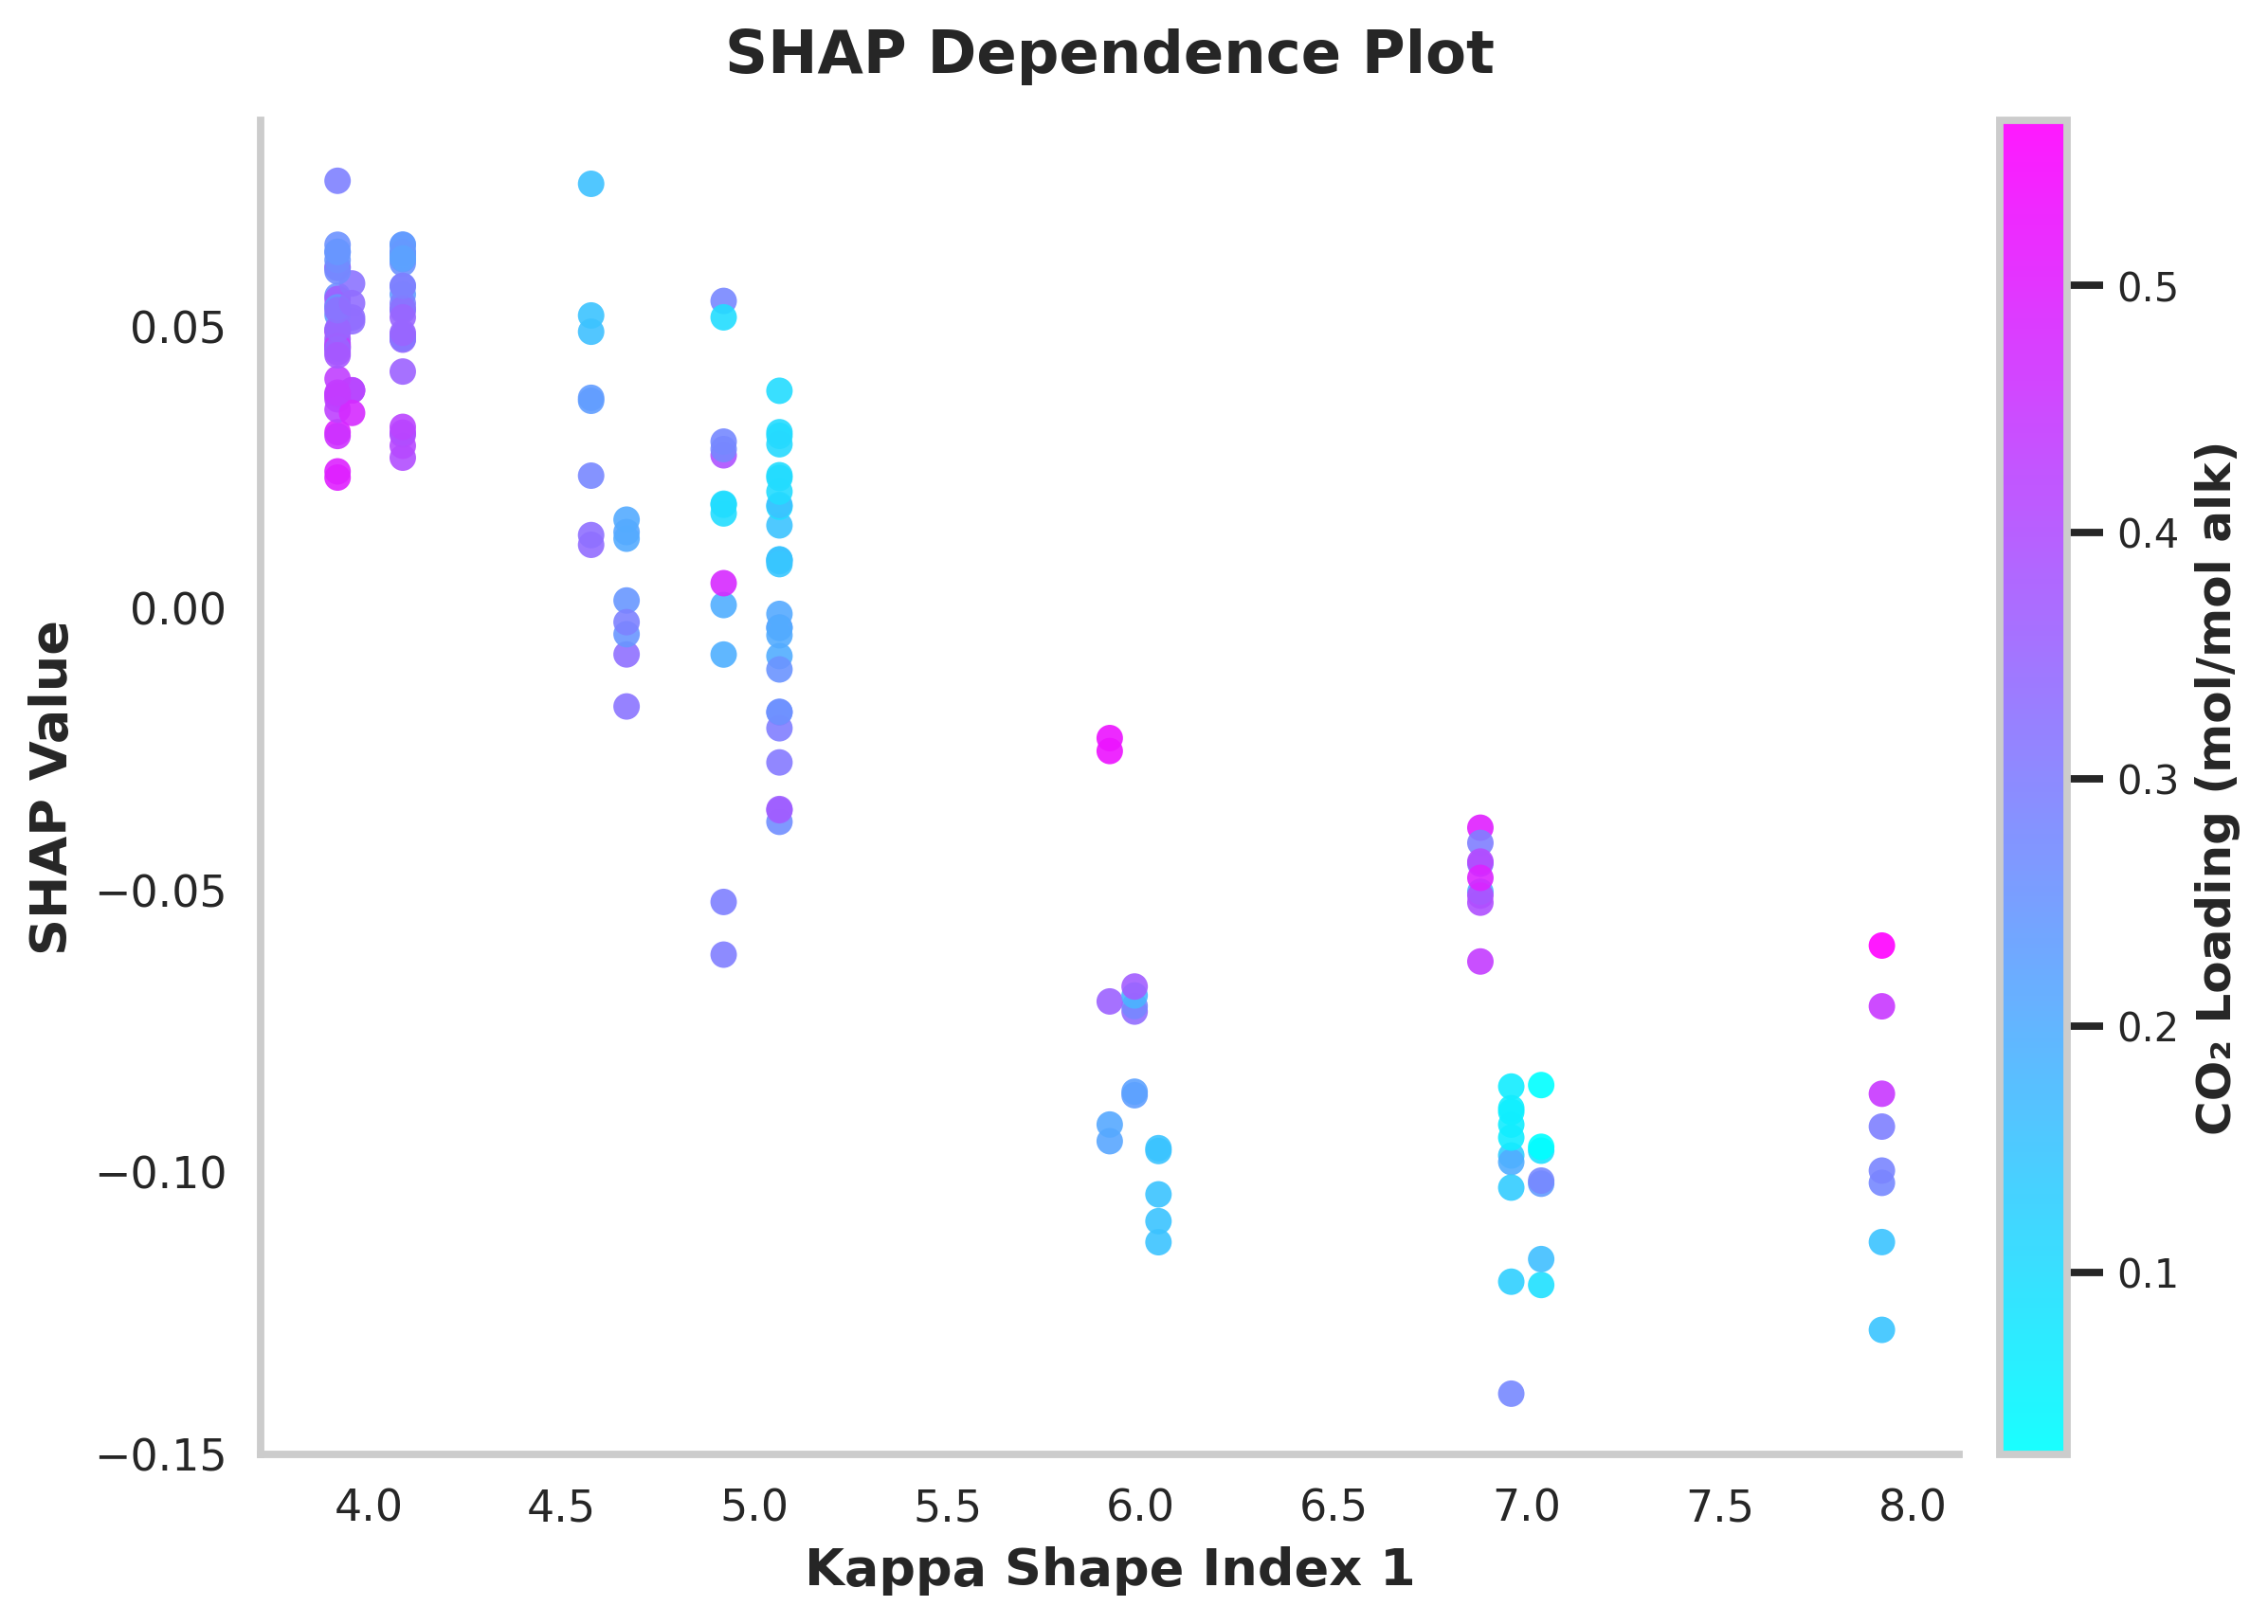

In [ ]:
# ============================================================
# PUBLICATION-QUALITY SHAP DEPENDENCE PLOT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Feature names
feature = "Kappa Shape Index 1"
interaction = "CO₂ Loading (mol/mol alk)"

# Indices of the features
feature_idx = X_display.columns.get_loc(feature)
interaction_idx = X_display.columns.get_loc(interaction)

# Data
x = X_display.iloc[:, feature_idx]
y = shap_values.values[:, feature_idx]
c = X_display.iloc[:, interaction_idx]

# Plot
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=300)

sc = ax.scatter(
    x,
    y,
    c=c,
    cmap="cool",
    s=45,
    edgecolors="none",
    alpha=0.9
)

# Labels
ax.set_xlabel(
    "Kappa Shape Index 1",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "SHAP Value",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "SHAP Dependence Plot",
    fontsize=15,
    fontweight="bold",
    pad=12
)

# Clean axes
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    labelsize=11,
    width=1.2,
    length=5
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(
    "CO₂ Loading (mol/mol alk)",
    fontsize=12,
    fontweight="bold"
)

cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

plt.show()

Screening and predicting top 5 performing amines using the chemically-informed Extra Trees model...



,Predicted_log_k,Predicted_Absorption_Rate
Proper_Amine_Name,,
3-(Methylamino)propylamine,-5.708308,0.000013
1-(2-Aminoethyl)piperazine,-5.712432,0.000006
Ethylenediamine,-5.755652,0.000003
Piperazine,-5.779212,0.000002
Monoethanolamine,-5.842469,0.000002


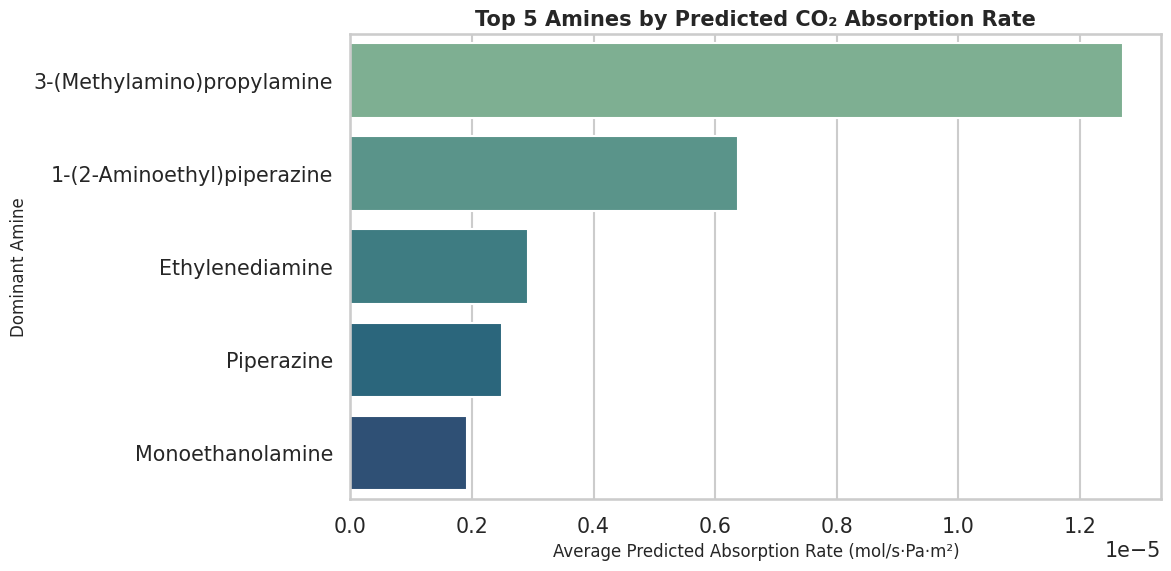

In [ ]:
# ============================================================
# 4. TRANSLATING ML TO CHEMISTRY: PREDICTING THE TOP 5 AMINES
# ============================================================
print(f"Screening and predicting top 5 performing amines using the chemically-informed {best_model_name} model...\n")

# Re-predict on the entire dataset (handling scaling if necessary)
if 'MLP' in best_model_name or best_model_name in ['SVM', 'KNN']:
    full_pred = best_model.predict(scaler.transform(X))
else:
    full_pred = best_model.predict(X)

# Attach predictions to a copy of the original dataframe
df_predictions = df.copy()
df_predictions['Predicted_log_k'] = full_pred

# Inverse transform log10 to get the actual absorption rate back
df_predictions['Predicted_Absorption_Rate'] = 10 ** df_predictions['Predicted_log_k']

# --------------------------------------------------------
# THE ULTIMATE FIX: Invincible Substring Mapping Function
# --------------------------------------------------------
def get_proper_amine_name(amine_raw):
    s = str(amine_raw).upper() # Convert to uppercase for case-insensitive matching

    # Check longest abbreviations first to prevent overlap (e.g., MDEA before DEA)
    if 'MDEA' in s: return 'Methyldiethanolamine'
    if '1-MPZ' in s: return '1-Methylpiperazine'
    if 'DEAB' in s: return '4-(Diethylamino)-2-butanol'
    if 'MAPA' in s: return '3-(Methylamino)propylamine'
    if 'AEEA' in s: return 'Aminoethylethanolamine'
    if 'DETA' in s: return 'Diethylenetriamine'
    if 'TETA' in s: return 'Triethylenetetramine'
    if 'AEP' in s: return '1-(2-Aminoethyl)piperazine'
    if 'EAE' in s: return '2-(Ethylamino)ethanol'
    if 'DGA' in s: return 'Diglycolamine'
    if 'TEA' in s: return 'Triethanolamine'
    if 'TPA' in s: return 'Tripropylamine'
    if 'AMP' in s: return '2-Amino-2-methyl-1-propanol'
    if 'DEA' in s: return 'Diethanolamine'
    if 'MEA' in s: return 'Monoethanolamine'
    if 'EDA' in s: return 'Ethylenediamine'
    if 'PZ' in s: return 'Piperazine'

    return amine_raw # Fallback if absolutely nothing matches

# Verify the 'dominant_amine' column exists from the original df load
if 'dominant_amine' in df.columns:

    # Apply the invincible mapping function directly to create a clean column
    df_predictions['Proper_Amine_Name'] = df_predictions['dominant_amine'].apply(get_proper_amine_name)

    # Group by the newly created, properly named column
    top_amines = df_predictions.groupby('Proper_Amine_Name')[['Predicted_log_k', 'Predicted_Absorption_Rate']].mean()

    # Sort descending to get the top 5
    top_amines = top_amines.sort_values(by='Predicted_log_k', ascending=False).head(5)

    display(top_amines)

    # Visualize the Top 5
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=top_amines['Predicted_Absorption_Rate'],
        y=top_amines.index,
        palette="crest"
    )
    plt.title('Top 5 Amines by Predicted CO₂ Absorption Rate', fontsize=15, weight='bold')
    plt.xlabel('Average Predicted Absorption Rate (mol/s·Pa·m²)', fontsize=12)
    plt.ylabel('Dominant Amine', fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("Notice: 'dominant_amine' column not found in df. Displaying the top 5 raw index entries:")
    top_entries = df_predictions.sort_values(by='Predicted_log_k', ascending=False).head(5)
    display(top_entries[['Predicted_log_k', 'Predicted_Absorption_Rate']])